# This project aims to predict students' test scores based on various features using machine learning algorithms. The dataset will be trained using deep learning. The goal is to achieve an R² > 0.80.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, TargetEncoder

In [3]:
path_train=r'/kaggle/input/competitions/playground-series-s6e1/train.csv'
df=pd.read_csv(path_train)

df.drop(columns=['id'],inplace=True)

In [4]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ MB


In [6]:
df.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [7]:
df=pd.get_dummies(df, drop_first=True)

In [8]:
df.head()

,age,study_hours,class_attendance,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,21,7.91,98.8,4.9,78.3,False,False,True,False,False,...,False,False,False,False,True,False,True,False,False,False
1,18,4.95,94.8,4.7,46.7,False,True,False,False,False,...,False,True,False,False,False,True,False,True,False,True
2,20,4.68,92.6,5.8,99.0,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
3,19,2.00,49.5,8.3,63.9,True,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
4,23,7.65,86.9,9.6,100.0,True,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         630000 non-null  int64  
 1   study_hours                 630000 non-null  float64
 2   class_attendance            630000 non-null  float64
 3   sleep_hours                 630000 non-null  float64
 4   exam_score                  630000 non-null  float64
 5   gender_male                 630000 non-null  bool   
 6   gender_other                630000 non-null  bool   
 7   course_b.sc                 630000 non-null  bool   
 8   course_b.tech               630000 non-null  bool   
 9   course_ba                   630000 non-null  bool   
 10  course_bba                  630000 non-null  bool   
 11  course_bca                  630000 non-null  bool   
 12  course_diploma              630000 non-null  bool   
 13  internet_acces

In [10]:
df.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


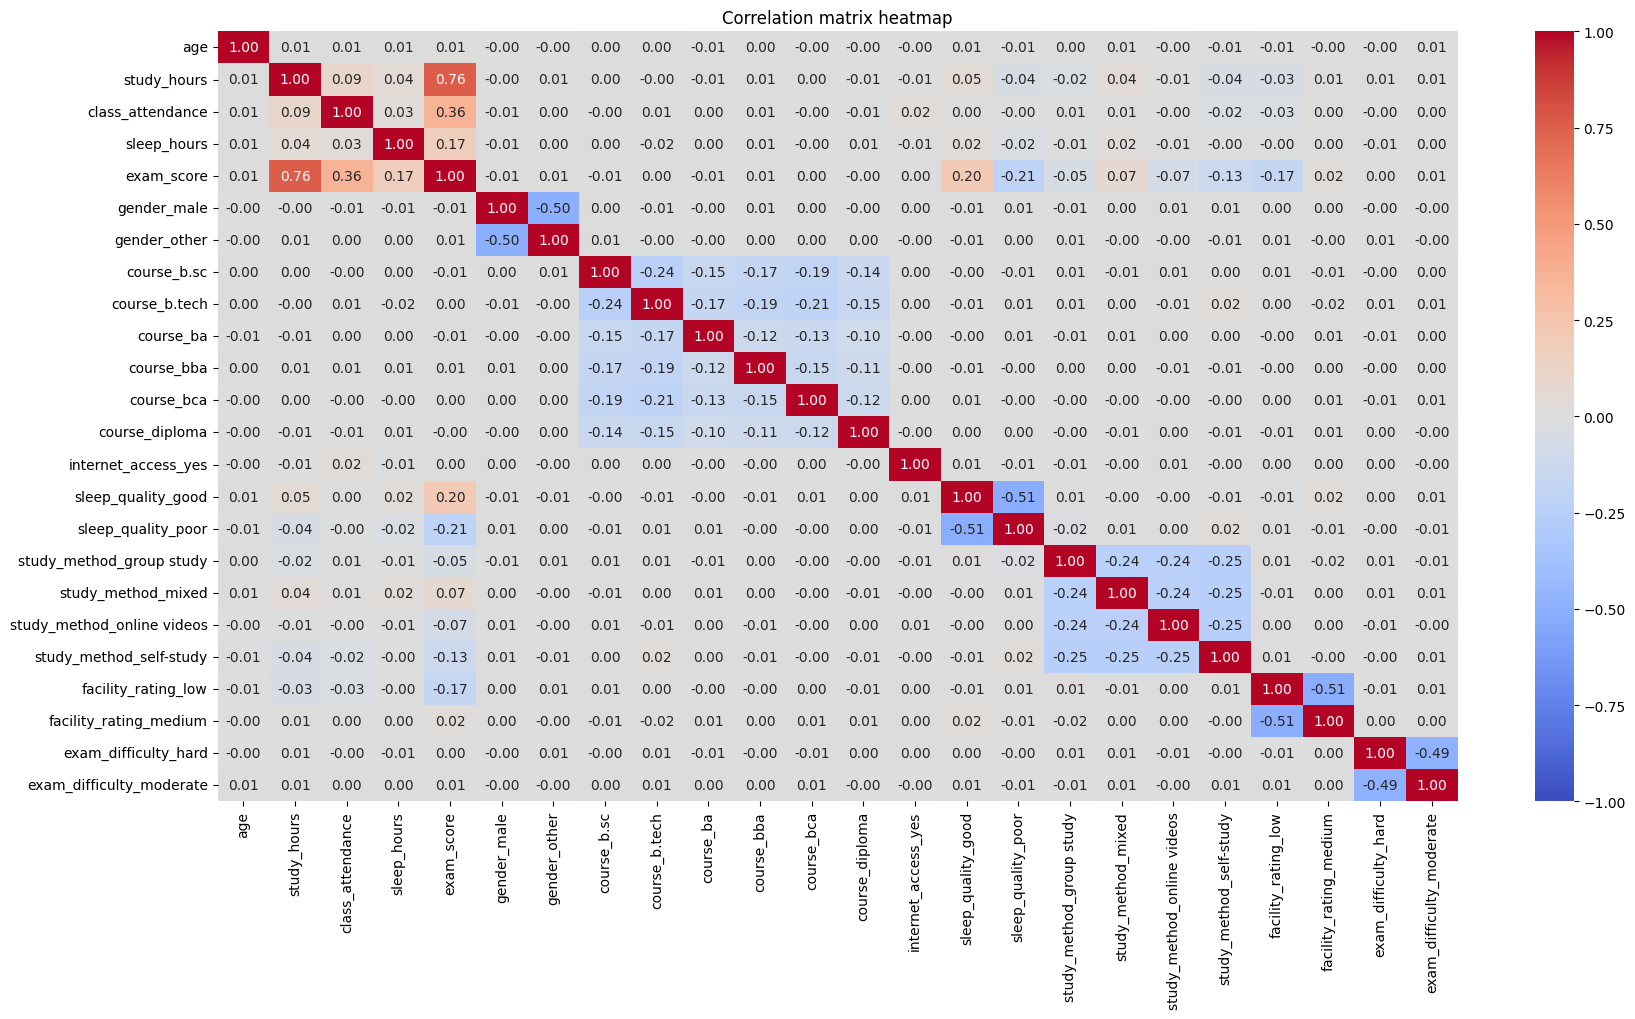

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# örnek: df your pandas DataFrame
corr = df.corr()

plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix heatmap')
plt.show()

In [12]:
x=df.drop('exam_score', axis=1)
y=df['exam_score']

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-03-29 19:21:32.084246: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774812092.337462      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774812092.410835      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774812092.983975      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774812092.984027      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774812092.984030      17 computation_placer.cc:177] computation placer alr

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler=StandardScaler()

In [16]:
x=scaler.fit_transform(x) #Normalizaston

In [17]:
model=Sequential()
model.add(Dense(80,activation='relu')) # hayal urunu
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1)) # sigmoid yok regression olduğu için


model.compile(loss='mean_squared_error', optimizer='adam')

2026-03-29 19:21:56.097559: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=.20,random_state=42)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

In [21]:
early_stop=EarlyStopping(monitor='val_loss',patience=20)

In [22]:
history=model.fit(x_train,y_train, epochs=100,callbacks=[early_stop], batch_size=64, validation_data=(x_test,y_test),verbose=1)



Epoch 1/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - loss: 189.4420 - val_loss: 81.2427
Epoch 2/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 82.2789 - val_loss: 81.3498
Epoch 3/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 81.3441 - val_loss: 81.0362
Epoch 4/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 81.0725 - val_loss: 80.5689
Epoch 5/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 80.7664 - val_loss: 85.6431
Epoch 6/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 80.5597 - val_loss: 80.2212
Epoch 7/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 80.5744 - val_loss: 81.2296
Epoch 8/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 80.3426 - val_loss: 79.9922
Epoch 9/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 79.9222 - val_loss: 80.3585
Epoch 10/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 79.9781 - val_loss: 81.6473
Epoch 11/100
7875/7875 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 80.1020 - val

In [23]:
predict=model.predict(x_test)

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [24]:
from sklearn.metrics import r2_score, mean_squared_error

In [25]:
r2_score(y_test,predict)

0.777448404770662

In [26]:
mean_squared_error(y_test,predict)**0.5

8.896619685068499

In [27]:
model.save('student_test_score_prediction.h5')

In [28]:
model.save('student_test_score_prediction.keras')

# In this project, we developed an artificial intelligence agent that predicts students' test scores based on various features using machine learning algorithms. The dataset was trained using deep learning. We achieved an R2 value of 0.77.